Import các thư viện cần thiết như Numpy và Pandas

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print(np.__version__)
print(pd.__version__)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000) # set up width 


2.3.5
2.3.3


Đọc datasets

In [2]:
df = pd.read_csv("../data/diabetes.csv")
print(df.shape) # Kích thước có 768 bệnh nhân và 9 cột bệnh lý
print('==================================================')
print(df.info()) #Thông tin kiểu dữ liệu của datasets
print('==================================================')


(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


Kiểm tra giá trị bất thường

In [3]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

zero_values = (df[cols] == 0).sum()

zero_table = pd.DataFrame({
    "Feature": zero_values.index,
    "Zero Values": zero_values.values,
    "Percentage %": (zero_values / len(df) * 100).round(3)
})

print("Các giá trị 0 bất thường")
display(zero_table)

df[cols] = df[cols].replace(0, np.nan)

Các giá trị 0 bất thường


,Feature,Zero Values,Percentage %
Glucose,Glucose,5,0.651
BloodPressure,BloodPressure,35,4.557
SkinThickness,SkinThickness,227,29.557
Insulin,Insulin,374,48.698
BMI,BMI,11,1.432


Thống kê dữ liệu

In [4]:
eda_summary = pd.DataFrame({
    "Feature": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (df.isnull().mean() * 100).round(3).values,
    "Mean": df.mean().round(3).values,
    "Std": df.std().round(3).values,
    "Min": df.min().values,
    "Max": df.max().values
})
print("Bảng thống kê dữ liệu")
display(eda_summary.sort_values('Missing %',ascending=False).reset_index(drop=True))

Bảng thống kê dữ liệu


,Feature,Missing Values,Missing %,Mean,Std,Min,Max
0,Insulin,374,48.698,155.548,118.776,14.000,846.00
1,SkinThickness,227,29.557,29.153,10.477,7.000,99.00
2,BloodPressure,35,4.557,72.405,12.382,24.000,122.00
3,BMI,11,1.432,32.457,6.925,18.200,67.10
4,Glucose,5,0.651,121.687,30.536,44.000,199.00
5,Pregnancies,0,0.000,3.845,3.370,0.000,17.00
6,DiabetesPedigreeFunction,0,0.000,0.472,0.331,0.078,2.42
7,Age,0,0.000,33.241,11.760,21.000,81.00
8,Outcome,0,0.000,0.349,0.477,0.000,1.00


Sau khi kiểm tra dữ liệu, phát hiện ra một số cột chứa giá trị 0 không hợp lý. 
Các giá trị này được coi là missing values và được chuyển thành NaN.

Cột Insulin có tỷ lệ thiếu cao nhất (~48,698%), tiếp theo là cột SkinThickness (~29,557%).
Các cột còn lại có tỷ lệ thiếu thấp (<5%).

In [47]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [11]:
# Xử lý giá trị trống bằng giá trị trung vị
df.fillna(df.median(), inplace=True)

In [13]:
# kiểm tra giá trị trống sau khi xử lý
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [ ]:
# KHÔNG CẦN ENCODING vì tất cả dữ liệu trong bảng đã là dạng số.

TRỰC QUAN HÓA DỮ LIỆU

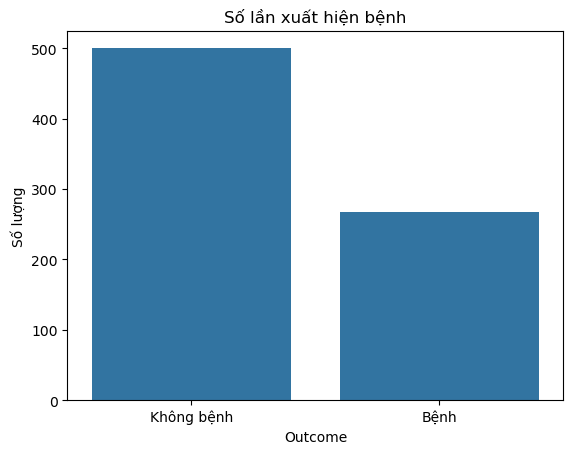

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='Outcome', data=df)
plt.xlabel("Outcome")
plt.ylabel("Số lượng")
plt.title('Số lần xuất hiện bệnh')
plt.xticks([0,1], ["Không bệnh","Bệnh"])
plt.show()

In [28]:
# Số lượng class
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

=> Biểu đồ cho thấy Dữ liệu bị mất cân bằng

CÂN BẰNG DỮ LIỆU (SMOTE)

In [15]:
# Tách X và Y
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [16]:
#  CÂN BẰNG
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=43)
X_resampled, Y_resampled = smote.fit_resample(X, df['Outcome'])

Outcome_count2 = Y_resampled.value_counts()

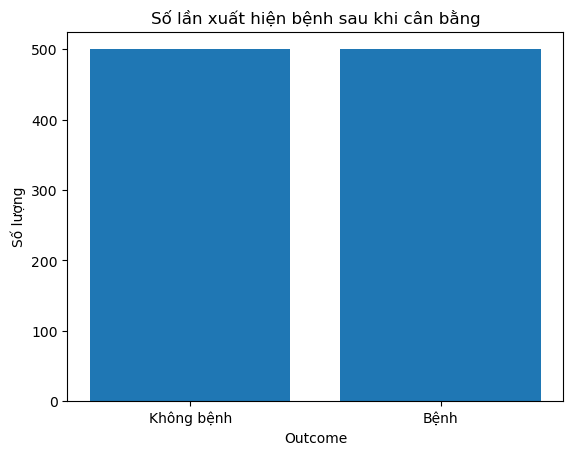

In [29]:
counts = Y_resampled.value_counts()

plt.bar(counts.index, counts.values)

plt.xlabel("Outcome")
plt.ylabel("Số lượng")
plt.title("Số lần xuất hiện bệnh sau khi cân bằng")

plt.xticks([0,1], ["Không bệnh","Bệnh"])

plt.show()

In [30]:
# đếm số lượng của các loại bệnh sau cân bằng
Y_resampled.value_counts()

Outcome
1    500
0    500
Name: count, dtype: int64

TRAIN/TEST

In [33]:
# chia dữ liệu thành train và test 8:2
X_train, X_test, Y_train, Y_test = train_test_split(X_resampled, Y_resampled, test_size=0.2, stratify=Y_resampled,random_state=0)

In [34]:
# (dòng, cột) của tập dữ liệu trước và sau khi chia train test
print(X_resampled.shape, X_train.shape, X_test.shape)

(1000, 8) (800, 8) (200, 8)


SCALING (STANDARDSCALER): giúp đưa dữ liệu về dạng có trung bình (mean) xấp xỉ bằng 0 và độ lệch chuẩn (std) bằng 1 
z = ( x - μ ) / σ

μ : mean
σ : standard deviation

In [51]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_df = pd.DataFrame(X_train, columns = X.columns)
print(X_train_df)

     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  DiabetesPedigreeFunction       Age
0       0.262529 -0.564817       0.642561       0.968868  0.466937  0.107250                 -0.100094 -0.160785
1      -0.607732 -0.683481      -0.870882      -1.813906 -0.993100 -1.152496                  0.708196 -0.872913
2       1.422877 -0.237342       0.550713       0.620211 -0.211901 -0.636436                 -0.716364 -0.427833
3       0.552616  1.147375      -0.959790      -0.104735 -0.211901 -1.339207                 -0.976734  1.441503
4      -1.187906 -0.720382      -0.791956       0.861860 -0.935283  0.051382                  0.040240 -1.050946
..           ...       ...            ...            ...       ...       ...                       ...       ...
795     0.842703  0.532947       3.042324      -0.104735 -0.211901  2.050186                 -0.800732  0.373311
796    -1.187906  0.615110      -0.199745      -0.104735 -0.211901  1.192256                 -0.